# Hardware-Native Hardened Posiform QUBO 생성

## 논문 재현: Pelofske, Hahn, Djidjev (2024)

논문의 hardware-native QUBO 생성 파이프라인을 재현한다.

**기존 구현과의 차이:**

| | 기존 (posiform.ipynb) | 본 노트북 (논문 방식) |
|---|---|---|
| 그래프 | complete graph (모든 쌍 연결) | **hardware topology** (Chimera/Pegasus/Zephyr) |
| 분할 | 순차 균등 분할 | **Kernighan-Lin recursive bisection** |
| Random QUBO | complete subgraph | **hardware subgraph 에지만** |
| Posiform | complete graph 위 clause | **hardware 에지 위 clause만** |
| QPU 실행 | embedding 필요 | **embedding 불필요** (이미 hardware-native) |

**파이프라인:**
1. Hardware graph 생성 (Chimera C16 / Pegasus P16 / Zephyr Z4,Z6)
2. KL recursive bisection → disjoint subgraph 분할
3. 각 subgraph에 discrete-coefficient random QUBO 생성 (hardware edge만)
4. 각 subproblem GS brute force
5. Concatenate → planted target
6. Posiform planting (hardware edge만)
7. `Q_final = Σ R_i + α × P`

In [1]:
import sys
!{sys.executable} -m pip install dwave-system dwave-neal dwave-networkx numpy matplotlib python-sat

In [1]:
import numpy as np
import networkx as nx
import dwave_networkx as dnx
from networkx.algorithms.community import kernighan_lin_bisection
from pysat.solvers import Minisat22
import random
import os
import time

np.set_printoptions(threshold=200, linewidth=150, precision=3, suppress=True)

COEFF_LIN2 = [-1, 1]
COEFF_LIN20 = [round(-1 + 0.1 * i, 1) for i in range(21)]

def _resolve_base_dir():
    """cwd가 'hardened_posiform/' 또는 repo root 둘 다 지원."""
    cwd = os.path.abspath(os.getcwd())
    return cwd if os.path.basename(cwd) == 'hardened_posiform' else os.path.join(cwd, 'hardened_posiform')


def _is_R_gs(sample, all_block_gs, partitions):
    """Sample이 R-GS인가? Partition별 GS membership (부동소수점 무관, 비트 단위)."""
    for gs_list, part in zip(all_block_gs, partitions):
        if not any(all(sample[v] == gs[v] for v in part) for gs in gs_list):
            return False
    return True


def _extract_inst_topo(inst):
    """인스턴스에서 사용된 (nodes, edges) 추출. edges는 (min, max) 정규화."""
    nodes, edges = set(), set()
    for (i, j) in list(inst['R_sum'].keys()) + list(inst['P'].keys()):
        nodes.add(i)
        if i != j:
            nodes.add(j)
            edges.add((min(i, j), max(i, j)))
    return nodes, edges


print("imports OK")

imports OK


## 1. Hardware Topology 생성

| Topology | 그래프 | Nodes | Edges | Max Degree |
|---|---|---|---|---|
| Chimera C16 | `chimera_graph(16)` | 2048 | 6016 | 6 |
| Pegasus P16 | `pegasus_graph(16)` | 5640 | 40484 | 15 |
| Zephyr Z4 | `zephyr_graph(4)` | 576 | 5032 | 20 |
| Zephyr Z6 | `zephyr_graph(6)` | 1248 | 11400 | 20 |

In [2]:
def get_hardware_graph(topology='pegasus', size=None):
    """
    D-Wave hardware topology 그래프 생성.

    Args:
        topology: 'chimera', 'pegasus', 'zephyr'
        size: topology 파라미터 (None이면 기본값)

    Returns:
        G: networkx.Graph (노드 = 큐빗, 에지 = 커플러)
    """
    if topology == 'chimera':
        m = size or 16
        G = dnx.chimera_graph(m)
        name = f'Chimera C{m}'
    elif topology == 'pegasus':
        m = size or 16
        G = dnx.pegasus_graph(m)
        name = f'Pegasus P{m}'
    elif topology == 'zephyr':
        m = size or 4
        G = dnx.zephyr_graph(m)
        name = f'Zephyr Z{m}'
    else:
        raise ValueError(f"Unknown topology: {topology}")

    degrees = [d for _, d in G.degree()]
    print(f"[{name}] nodes={G.number_of_nodes()}, edges={G.number_of_edges()}, "
          f"degree: min={min(degrees)}, max={max(degrees)}, avg={np.mean(degrees):.1f}")
    return G, name

## 2. Kernighan-Lin Recursive Bisection

논문 Section 2.2: "we partition the hardware graph into disjoint induced subgraphs using Kernighan-Lin recursive bisection"

재귀적으로 이등분하여 각 partition이 `max_sub_size` 이하가 될 때까지 분할.

In [3]:
def kl_recursive_bisection(G, max_sub_size=15):
    """
    Kernighan-Lin recursive bisection으로 그래프를 disjoint subgraph로 분할.

    논문 방식: 각 partition이 max_sub_size 이하가 될 때까지 재귀적으로 이등분.

    Args:
        G: networkx.Graph
        max_sub_size: 각 partition 최대 크기

    Returns:
        partitions: [set of nodes, ...] — disjoint partition 리스트
    """
    nodes = set(G.nodes())
    if len(nodes) <= max_sub_size:
        return [nodes]

    sub = G.subgraph(nodes).copy()
    try:
        A, B = kernighan_lin_bisection(sub)
    except nx.NetworkXError:
        partitions = []
        for comp in nx.connected_components(sub):
            partitions.extend(kl_recursive_bisection(G.subgraph(comp).copy(), max_sub_size))
        return partitions

    result = []
    for part in [A, B]:
        if len(part) <= max_sub_size:
            result.append(part)
        else:
            result.extend(kl_recursive_bisection(G.subgraph(part).copy(), max_sub_size))

    return result

## 3. Hardware-Native Random QUBO + Posiform 생성

핵심: **hardware graph의 에지에만** 계수를 배정.
complete graph와 달리, 존재하지 않는 에지에는 coupling이 없다.

In [4]:
def gen_hardware_random_qubo(G, variables, coeff_type='lin2'):
    """
    Hardware subgraph 위에 random discrete-coefficient QUBO 생성.
    논문 Step 2: hardware edge에만 coupling 배정.
    """
    coeffs = COEFF_LIN2 if coeff_type == 'lin2' else COEFF_LIN20
    var_set = set(variables)
    Q = {}

    for v in variables:
        Q[(v, v)] = random.choice(coeffs)

    sub = G.subgraph(var_set)
    for i, j in sub.edges():
        lo, hi = min(i, j), max(i, j)
        Q[(lo, hi)] = random.choice(coeffs)

    return Q

def solve_subproblem_brute_force(Q, variables):
    """
    Brute force로 subproblem QUBO의 GS 계산.
    GS의 모든 assignment를 반환.

    Returns:
        best_assignment: {node: 0 or 1} (첫 번째 GS)
        best_energy: float
        num_degenerate: int
        all_gs_assignments: [{node: 0 or 1}, ...] (모든 GS)
    """
    n = len(variables)
    if n > 23:
        raise ValueError(f"Brute force 불가: subgraph size {n} > 23")

    var_list = sorted(variables)
    var_to_idx = {v: i for i, v in enumerate(var_list)}

    linear = []
    quad = []
    for (i, j), w in Q.items():
        if i == j:
            linear.append((var_to_idx[i], w))
        else:
            quad.append((var_to_idx[i], var_to_idx[j], w))

    # linear 중복 제거
    linear_map = {}
    for idx, w in linear:
        linear_map[idx] = linear_map.get(idx, 0) + w
    linear = [(idx, w) for idx, w in linear_map.items() if w != 0]
    quad = [(a, b, w) for a, b, w in quad if w != 0]

    best_energy = float('inf')
    best_bits = 0
    num_degenerate = 0
    all_gs_bits = []

    for bits in range(1 << n):
        energy = 0.0
        for idx, w in linear:
            if (bits >> (n - 1 - idx)) & 1:
                energy += w
        for a, b, w in quad:
            if ((bits >> (n - 1 - a)) & 1) and ((bits >> (n - 1 - b)) & 1):
                energy += w

        if energy < best_energy - 1e-12:
            best_energy = energy
            best_bits = bits
            num_degenerate = 1
            all_gs_bits = [bits]
        elif abs(energy - best_energy) < 1e-12:
            num_degenerate += 1
            all_gs_bits.append(bits)

    # assignment 변환
    def bits_to_assignment(bits):
        return {v: (bits >> (n - 1 - i)) & 1 for i, v in enumerate(var_list)}

    best_assignment = bits_to_assignment(best_bits)
    all_gs_assignments = [bits_to_assignment(b) for b in all_gs_bits]

    return best_assignment, best_energy, num_degenerate, all_gs_assignments

print("brute force + GS 열거 함수 정의 완료")

brute force + GS 열거 함수 정의 완료


In [5]:
def posiform_planting_hardware(G, target_assignment, alpha):
    """
    Hardware graph 위에 posiform planting.
    논문 Step 5: hardware edge에만 clause 생성.

    MiniSat으로 2-SAT uniqueness 검증.

    Args:
        G: hardware graph
        target_assignment: {node: 0 or 1}
        alpha: posiform 계수 (스케일링)

    Returns:
        Q_posiform: {(i,j): weight} — posiform QUBO
    """
    nodes = sorted(target_assignment.keys())
    n = len(nodes)
    node_to_idx = {v: i for i, v in enumerate(nodes)}
    edges = [(min(u, v), max(u, v)) for u, v in G.subgraph(nodes).edges()] # edges는 이미 G.subgraph(nodes).edges()로 hardware-valid coupler만 포함

    if not edges:
        return {}

    Q_posiform = {}
    clauses_cnf = []
    all_tuples = [(0, 0), (0, 1), (1, 0), (1, 1)]
    max_clauses = 1000 * n

    def add_posiform_term(i, j):
        target_tuple = (target_assignment[i], target_assignment[j])
        wrong_tuples = [t for t in all_tuples if t != target_tuple]
        wi, wj = random.choice(wrong_tuples)
        lo, hi = min(i, j), max(i, j)

        if wi == 0 and wj == 0:
            Q_posiform[(i, i)] = Q_posiform.get((i, i), 0) - alpha
            Q_posiform[(j, j)] = Q_posiform.get((j, j), 0) - alpha
            Q_posiform[(lo, hi)] = Q_posiform.get((lo, hi), 0) + alpha
        elif wi == 0 and wj == 1:
            Q_posiform[(j, j)] = Q_posiform.get((j, j), 0) + alpha
            Q_posiform[(lo, hi)] = Q_posiform.get((lo, hi), 0) - alpha
        elif wi == 1 and wj == 0:
            Q_posiform[(i, i)] = Q_posiform.get((i, i), 0) + alpha
            Q_posiform[(lo, hi)] = Q_posiform.get((lo, hi), 0) - alpha
        else:
            Q_posiform[(lo, hi)] = Q_posiform.get((lo, hi), 0) + alpha

        # CNF clause
        lit_i = (node_to_idx[i] + 1) if wi == 0 else -(node_to_idx[i] + 1)
        lit_j = (node_to_idx[j] + 1) if wj == 0 else -(node_to_idx[j] + 1)
        clauses_cnf.append([lit_i, lit_j])

    def check_uniqueness():
        with Minisat22() as solver:
            for clause in clauses_cnf:
                solver.add_clause(clause)
            blocking = []
            for node in nodes:
                idx = node_to_idx[node] + 1
                blocking.append(-idx if target_assignment[node] == 1 else idx)
            solver.add_clause(blocking)
            return not solver.solve()

    check_interval = max(1, n // 4)

    for step in range(max_clauses):
        # hardware edge에서 랜덤 선택
        i, j = random.choice(edges) # step 2에서 만든 edges 안에서만 random choice
        add_posiform_term(i, j) # wrong tuple → CNF clause + Q 업데이트

        if (step + 1) % check_interval == 0:
            if check_uniqueness(): # MiniSat 2-SAT — target이 유일한 해인지 검사
                print(f"  [posiform] {step + 1} clauses로 유일성 확보")
                Q_posiform = {k: v for k, v in Q_posiform.items() if abs(v) > 1e-15}
                return Q_posiform

    print(f"  [Warning] {max_clauses} clauses 후에도 유일성 미확보")
    Q_posiform = {k: v for k, v in Q_posiform.items() if abs(v) > 1e-15}
    return Q_posiform


print("Posiform planting 함수 정의 완료")

Posiform planting 함수 정의 완료


## 4. 전체 파이프라인: Hardware-Native Hardened Posiform

**Reference 구현 (pseudocode)** — 실제 실험 실행은 Cell 15의 `_generate_single_instance` (multiprocessing worker 버전) 가 담당.
이 함수는 single-call 형태로 파이프라인을 한눈에 보여주는 용도로 보존 — 논문 작성 시 알고리즘 박스로 사용 가능.

```python
def gen_hardware_native_qubo(topology='pegasus', topo_size=None,
                              max_sub_size=15, coeff_type='lin2',
                              posiform_scale=0.1, seed=None):
    """
    Hardware-Native Hardened Posiform QUBO 생성 (논문 전체 파이프라인).
    """
    if seed is not None:
        random.seed(seed)

    G, topo_name = get_hardware_graph(topology, topo_size)

    t0 = time.time()
    partitions = kl_recursive_bisection(G, max_sub_size)
    bisection_time = time.time() - t0
    print(f"  [KL bisection] {len(partitions)} partitions, {bisection_time:.2f}s")

    t0 = time.time()
    random_qubos = []
    target_assignment = {}
    total_random_energy = 0.0
    total_degenerate = 1

    for part in partitions:
        variables = sorted(part)
        R = gen_hardware_random_qubo(G, variables, coeff_type)
        assignment, energy, deg, _, _ = solve_subproblem_brute_force(R, variables)

        target_assignment.update(assignment)
        random_qubos.append(R)
        total_random_energy += energy
        total_degenerate *= deg

    bf_time = time.time() - t0
    print(f"  [Random QUBO + BF] {bf_time:.2f}s, "
          f"total deg={total_degenerate}")

    target_str = ''.join(str(target_assignment[n]) for n in sorted(target_assignment))

    t0 = time.time()
    Q_posiform = posiform_planting_hardware(G, target_assignment, posiform_scale)
    posiform_time = time.time() - t0
    print(f"  [Posiform] {posiform_time:.2f}s, {len(Q_posiform)} terms")

    Q_final = {}
    for R in random_qubos:
        for key, val in R.items():
            Q_final[key] = Q_final.get(key, 0) + val
    for key, val in Q_posiform.items():
        Q_final[key] = Q_final.get(key, 0) + val
    Q_final = {k: v for k, v in Q_final.items() if abs(v) > 1e-15}

    target_energy = 0.0
    for (i, j), w in Q_final.items():
        xi = target_assignment.get(i, 0)
        xj = target_assignment.get(j, 0) if i != j else 1
        if i == j:
            target_energy += w * xi
        else:
            target_energy += w * xi * xj

    info = {
        'topology': topo_name,
        'n': len(target_assignment),
        'num_partitions': len(partitions),
        'partition_sizes': sorted([len(p) for p in partitions]),
        'coeff_type': coeff_type,
        'posiform_scale': posiform_scale,
        'total_degeneracy': total_degenerate,
        'random_total_energy': total_random_energy,
        'target_energy': target_energy,
        'num_qubo_terms': len(Q_final),
        'num_edges_hardware': G.number_of_edges(),
    }

    return Q_final, target_assignment, info
```


## 7. QPU 호환성 사전 점검

D-Wave QPU에 연결하여 active 큐빗/커플러 정보를 확인하고, 인스턴스 호환성을 미리 검증한다. 인스턴스 생성·실험의 prereq.

### API 토큰 설정
1. https://cloud.dwavesys.com → **API Tokens** → 토큰 복사
2. 아래 셀의 `MY_TOKEN = "DEV-여기에붙여넣기"`로 변경

In [6]:
# ═══ QPU 호환성 사전 점검 ═══
# INST_TOPO에 맞는 QPU에 자동 연결 (solver={'topology__type': INST_TOPO}).
# 한 계정 토큰으로 여러 칩 접근 가능 (계정에 활성화된 solver 한정).
from dwave.system import DWaveSampler

# ─── 토큰 + 실험 타깃 (셀 7과 공유: 여기서 정의 → 셀 7에서 그대로 사용) ───
MY_TOKEN = "yXwP-644aea66ae6f2920550b5c28a53d47e018fdf32e"
INST_TOPO = 'pegasus'           # 'pegasus' (Advantage_system) or 'zephyr' (Advantage2_prototype)
INST_TOPO_SIZE = 16             # 라벨링 + ideal 비교용. pegasus=16, zephyr=4 or 6
INST_COEFF = 'lin2'             # 'lin2' or 'lin20'
NUM_INSTANCES = 500             # 인스턴스 개수

# ─── QPU 연결 (topology 필터로 자동 선택) ───
try:
    if MY_TOKEN:
        qpu_check = DWaveSampler(token=MY_TOKEN,
                                  solver={'topology__type': INST_TOPO})
    else:
        qpu_check = DWaveSampler(solver={'topology__type': INST_TOPO})
except Exception as e:
    raise RuntimeError(
        f"INST_TOPO='{INST_TOPO}' 칩 연결 실패. "
        f"Leap 계정에 해당 토폴로지 solver가 활성화되어 있는지 확인하세요. ({type(e).__name__}: {e})")

# QPU active subgraph (dnx pegasus/zephyr/chimera 서브클래스, 결함 큐빗·커플러 제외)
G_qpu = qpu_check.to_networkx_graph()
qpu_nodes_pre = set(G_qpu.nodes())
qpu_edges_pre = set((min(u, v), max(u, v)) for u, v in G_qpu.edges())
qpu_topo_type = qpu_check.properties.get('topology', {}).get('type', '?')

print(f"QPU: {qpu_check.solver.name}")
print(f"  Topology: {qpu_topo_type}")
print(f"  Active: {len(qpu_nodes_pre)} qubits, {len(qpu_edges_pre)} couplers")

# 일관성 sanity check (solver filter로 이미 매칭됐지만 한 번 더)
if qpu_topo_type != INST_TOPO:
    raise RuntimeError(
        f"INST_TOPO='{INST_TOPO}'와 실제 QPU topology='{qpu_topo_type}' 불일치 (예상치 못한 mismatch).")

# ─── Ideal {INST_TOPO}{INST_TOPO_SIZE}와 비교 ───
G_ideal, _ = get_hardware_graph(INST_TOPO, INST_TOPO_SIZE)
ideal_nodes = set(G_ideal.nodes())
ideal_edges = set((min(u, v), max(u, v)) for u, v in G_ideal.edges())

print(f"\n[Ideal {INST_TOPO}{INST_TOPO_SIZE}]")
print(f"  {len(ideal_nodes)} qubits, {len(ideal_edges)} couplers")
print(f"  결함 큐빗 (ideal − active): {len(ideal_nodes - qpu_nodes_pre)}")
print(f"  결함 커플러 (ideal − active): {len(ideal_edges - qpu_edges_pre)}")
print(f"  QPU active ⊆ ideal? nodes={qpu_nodes_pre.issubset(ideal_nodes)}, "
      f"edges={qpu_edges_pre.issubset(ideal_edges)}")

if not qpu_nodes_pre.issubset(ideal_nodes) or not qpu_edges_pre.issubset(ideal_edges):
    print(f"  [⚠ Warning] QPU active set이 ideal {INST_TOPO}{INST_TOPO_SIZE}의 부분집합이 아님 — "
          f"INST_TOPO_SIZE 값 확인 필요 (P15? P16? Z4? Z6?).")

# ─── 인스턴스 호환성 점검 (없으면 graceful skip) ───
valid = 0
try:
    inst_list_check, inst_meta_check = load_instances(NUM_INSTANCES,
                                                       topo=INST_TOPO,
                                                       topo_size=INST_TOPO_SIZE,
                                                       coeff=INST_COEFF)

    fail_node = fail_edge = fail_both = 0
    fail_examples = []
    for idx, inst in enumerate(inst_list_check):
        nodes, edges = _extract_inst_topo(inst)
        n_ok = nodes.issubset(qpu_nodes_pre)
        e_ok = edges.issubset(qpu_edges_pre)
        if n_ok and e_ok:
            valid += 1
        else:
            if not n_ok and not e_ok:
                fail_both += 1
            elif not n_ok:
                fail_node += 1
            else:
                fail_edge += 1
            if len(fail_examples) < 3:
                missing_n = nodes - qpu_nodes_pre
                missing_e = edges - qpu_edges_pre
                fail_examples.append((idx, len(missing_n), len(missing_e)))

    print(f"\n[인스턴스 호환성 ({NUM_INSTANCES}개, {INST_COEFF})]")
    print(f"  ✓ identity embedding 가능: {valid} ({valid/NUM_INSTANCES*100:.1f}%)")
    print(f"  ✗ 결함 큐빗만 사용: {fail_node}")
    print(f"  ✗ 결함 커플러만 사용: {fail_edge}")
    print(f"  ✗ 둘 다 사용: {fail_both}")
    if fail_examples:
        print(f"  실패 예시 (idx, missing nodes, missing edges):")
        for ex in fail_examples:
            print(f"    inst[{ex[0]}]: {ex[1]} nodes, {ex[2]} edges 누락")

except (FileNotFoundError, NameError) as e:
    print(f"\n[인스턴스 호환성] 인스턴스 파일 또는 load_instances 함수 없음 — "
          f"셀 7을 먼저 실행해서 active 인스턴스를 생성한 뒤 이 셀을 다시 돌리세요.")
    print(f"  ({type(e).__name__}: {e})")

# ─── Session 1 비용 외삽 (실제 valid 인스턴스 기반) ───
n_alpha_s1 = 12
per_problem_ms = 43.37  # Advantage_system4.1, num_reads=100 측정값 (다른 칩은 다를 수 있음)
expected_s = n_alpha_s1 * valid * per_problem_ms / 1000
budget_s = 4.5 * 60

print(f"\n[Session 1 raw access time 외삽 ({n_alpha_s1} α × {valid} valid inst × 100 reads)]")
print(f"  예상: {expected_s:.1f} s = {expected_s/60:.2f} 분")
print(f"  4.5분 예산 활용률: {expected_s/budget_s*100:.1f}%")
if valid == 0:
    print(f"  [—] valid 인스턴스 0개 — 셀 7 먼저 실행 후 점검 셀 재실행")
elif expected_s > budget_s:
    print(f"  [⚠] 예산 초과 — α 점 수 줄이거나 num_reads 감소 필요")
elif expected_s < budget_s * 0.7:
    print(f"  [ℹ] 여유 큼 — α 점 추가 또는 stretch goal 활용 가능")
else:
    print(f"  [✓] 예산에 적정")


QPU: Advantage_system4.1
  Topology: pegasus
  Active: 5627 qubits, 40279 couplers
[Pegasus P16] nodes=5640, edges=40484, degree: min=6, max=15, avg=14.4

[Ideal pegasus16]
  5640 qubits, 40484 couplers
  결함 큐빗 (ideal − active): 13
  결함 커플러 (ideal − active): 205
  QPU active ⊆ ideal? nodes=True, edges=True

[인스턴스 호환성] 인스턴스 파일 또는 load_instances 함수 없음 — 셀 7을 먼저 실행해서 active 인스턴스를 생성한 뒤 이 셀을 다시 돌리세요.
  (NameError: name 'load_instances' is not defined)

[Session 1 raw access time 외삽 (12 α × 0 valid inst × 100 reads)]
  예상: 0.0 s = 0.00 분
  4.5분 예산 활용률: 0.0%
  [—] valid 인스턴스 0개 — 셀 7 먼저 실행 후 점검 셀 재실행


## 8. 인스턴스 사전 생성 + 저장/로드

인스턴스 생성(KL bisection + brute force + posiform)이 오래 걸리므로, 한 번 만들어 pickle로 저장해두고 실험마다 재활용.

- `instances_pegasus16_lin2_500.pkl` — 500개
- `instances_pegasus16_lin2_1000.pkl` — 1000개

In [ ]:
# ═══ 인스턴스 사전 생성 + 저장 (병렬화) ═══
# 논문(Pelofske, Hahn, Djidjev 2024)의 hardware-native 정의에 따라 QPU active subgraph 위에서 생성.
#
# 흐름: 생성 → QPU 호환성 검증 (strict, 전수 통과 필수) → pickle 저장
#       검증 실패 시 RuntimeError로 pickle 저장 차단.
#
# Prereq: 점검 셀(## 7)이 먼저 같은 커널에서 실행되어 다음 변수가 정의되어 있어야 함.
#   - qpu_check: DWaveSampler 객체 (calibration·active set 정보 보유)
#   - qpu_nodes_pre: set of active qubit indices
#   - qpu_edges_pre: set of (min, max) 표준화된 active coupler tuples

import pickle
import os
from concurrent.futures import ProcessPoolExecutor, as_completed
from functools import partial

# ─── 하이퍼파라미터 (필요 시 조정) ───
INST_TOPO = 'pegasus'         # 'pegasus' / 'zephyr' / 'chimera' — 점검 셀의 INST_TOPO와 일치 필수
INST_TOPO_SIZE = 16           # 라벨링 + 파일명. pegasus=16, zephyr=4 or 6
INST_COEFF = 'lin2'           # 'lin2' ({-1,+1}) or 'lin20' (-1.0..1.0 step 0.1)
INST_COUNTS = [100, 200]      # 생성할 인스턴스 수 목록
INST_MAX_SUB = 16             # KL bisection partition 최대 크기 (brute force 가능 ≤ 23)
NUM_WORKERS = os.cpu_count()  # 병렬 워커 수
# ────────────────────────────────────

_cwd = os.path.abspath(os.getcwd())
_base = _cwd if os.path.basename(_cwd) == 'hardened_posiform' else os.path.join(_cwd, 'hardened_posiform')
inst_dir = os.path.join(_base, 'instances')
os.makedirs(inst_dir, exist_ok=True)

def _generate_single_instance(inst, G, max_sub, coeff):
    """단일 인스턴스 생성 (워커 함수, multiprocessing fork로 호출).

    Hardware-native hardened posiform 파이프라인:
      1. KL bisection: G → 작은 partition들 (각 ≤ max_sub 노드)
      2. 각 partition에 random QUBO R_i 생성 + brute force로 partition GS 계산
      3. target := partition GS들의 union (각 partition이 disjoint이므로 union이 R의 GS)
      4. posiform P planting (P가 target을 unique GS로 강제 — MiniSat 2-SAT 검증)

    Returns dict with: R_sum, P, target, target_str, t_energy_r, t_energy_p, ...
    """
    random.seed(inst * 53)  # 재현성: inst 인덱스로 deterministic seed

    parts = kl_recursive_bisection(G, max_sub)

    random_qubos = []    # 각 partition의 R_i 저장 (나중에 R_sum으로 합칠 용도)
    target = {}          # 노드별 target bit (partition GS들의 union)
    total_deg = 1        # 전체 R의 GS 축퇴도 = 각 partition 축퇴도의 곱
    all_block_gs = []    # 각 partition의 모든 GS 비트 (α=0 R-GS check용)

    for part in parts:
        variables = sorted(part)
        R = gen_hardware_random_qubo(G, variables, coeff)
        # brute force enumeration: 2^|partition| 모든 비트열에서 GS 확정
        assignment, energy, deg, gs_assignments = solve_subproblem_brute_force(R, variables)
        target.update(assignment)
        random_qubos.append(R)
        total_deg *= deg
        all_block_gs.append(gs_assignments)

    # Posiform planting: P가 target에서 0 에너지, 다른 비트열에서 양 에너지
    # MiniSat이 unique 2-SAT solution 보장할 때까지 clause 추가 후 반환
    P = posiform_planting_hardware(G, target, 1.0)

    # R_sum = Σ R_i (partition들이 disjoint이므로 키 충돌 없는 단순 합)
    R_sum = {}
    for R in random_qubos:
        for k, v in R.items():
            R_sum[k] = R_sum.get(k, 0) + v

    # target에서의 R, P 에너지 (Q_final = R + α·P의 target_energy = t_energy_r + α·t_energy_p)
    t_energy_r = sum(w * target.get(i, 0) * (target.get(j, 0) if i != j else 1)
                     if i != j else w * target.get(i, 0)
                     for (i, j), w in R_sum.items())
    t_energy_p = sum(w * target.get(i, 0) * (target.get(j, 0) if i != j else 1)
                     if i != j else w * target.get(i, 0)
                     for (i, j), w in P.items())

    sorted_nodes = sorted(target.keys())
    target_str = ''.join(str(target[nd]) for nd in sorted_nodes)

    return {
        'R_sum': R_sum,
        'P': P,
        'target': target,
        'target_str': target_str,
        'sorted_nodes': sorted_nodes,
        'n': len(target),
        't_energy_r': t_energy_r,
        't_energy_p': t_energy_p,
        'total_degeneracy': total_deg,
        'seed': inst * 53,
        'all_block_gs': all_block_gs,           # 각 partition의 GS 후보 dict 리스트 (α=0 R-GS check용)
        'partitions': [sorted(p) for p in parts],  # 각 partition의 노드 리스트 (정렬)
    }

def _verify_qpu_compatibility(all_instances, qpu_nodes, qpu_edges):
    """모든 인스턴스가 D-Wave QPU에 identity embedding 가능한지 strict 검증.

    Identity embedding (변수 i → 큐빗 i 1:1 매핑) 조건 (D-Wave SDK):
      1. 인스턴스의 모든 변수(linear/quadratic key의 노드) ⊆ active qubit set
      2. 인스턴스의 모든 quadratic 항 (i,j) ⊆ active coupler set

    하나라도 결함 큐빗/커플러를 사용하면 SAPI에서 EmbeddingError 발생 → 사전에 차단.

    Args:
        all_instances: 인스턴스 dict 리스트 (각 dict에 'R_sum', 'P' 키)
        qpu_nodes: set of active qubit indices (qpu_check.nodelist에서 추출)
        qpu_edges: set of (min, max) tuple — 활성 coupler (qpu_check.edgelist에서 추출)

    Returns:
        (ok, failures): ok는 모든 인스턴스 통과 여부 (bool)
                         failures는 [(idx, missing_nodes_count, missing_edges_count), ...]
                         실패한 인스턴스가 사용한 결함 노드/에지 개수만 기록 (구체적 ID는 미보존 — 디버깅 시 _extract_inst_topo 재호출).

    Note:
        posiform_planting_hardware가 abs(v) > 1e-15 필터로 0 cancellation 항을 dict에서 제거.
        그 (i,j)가 결함 커플러여도 검증에서 누락될 수 있으나, 인스턴스가 weight=0으로 안 쓰는
        항이라 QPU 제출 시 문제 없음 (false negative만 가능, false positive는 없음).
    """
    failures = []

    # 인스턴스 단위 순회 — 첫 실패에서 break하지 않고 끝까지 검사해야 하는 이유:
    #   상위 호출부가 "100개 중 어떤 인덱스가, 얼마나 결함을 썼는지" 통계를 받아
    #   재생성 정책(전수 재생성 vs 결함 인스턴스만 교체)을 결정한다.
    for idx, inst in enumerate(all_instances):
        # R + P 둘 다에서 사용된 노드/에지 집합을 합쳐서 추출.
        # R-only 또는 P-only 항도 SAPI 제출 시 같은 그래프로 전송되므로 어느 쪽이든 결함이면 fail.
        nodes, edges = _extract_inst_topo(inst)

        # short-circuit OR — nodes 검사 통과해도 edges가 결함 coupler를 쓰면 SAPI EmbeddingError 발생.
        # 따라서 두 조건 중 하나라도 위반하면 인스턴스 전체를 fail로 마킹.
        if not nodes.issubset(qpu_nodes) or not edges.issubset(qpu_edges):
            # set difference로 어느 노드/에지가 active set 바깥인지 추출.
            #   missing_n: 인스턴스가 쓰지만 QPU에 비활성인 큐빗 (calibration 시점에 fail 처리된 것).
            #   missing_e: 인스턴스가 쓰지만 QPU에 비활성인 coupler.
            missing_n = nodes - qpu_nodes
            missing_e = edges - qpu_edges

            # 큰 인스턴스 수에 대비해 size만 저장 (set 자체는 인스턴스당 수십~수백 KB).
            # 통과율 통계 + idx로 재현 가능하므로 충분.
            failures.append((idx, len(missing_n), len(missing_e)))

    # ok = True 조건: failures 리스트가 비었음 = 모든 인스턴스가 active subgraph 안에 fit.
    return (len(failures) == 0, failures)

def generate_and_save_instances(num_instances, G, topo_label, topo_size, coeff, max_sub,
                                qpu_nodes, qpu_edges, extra_meta=None):
    """주어진 그래프 G 위에서 인스턴스 생성 → QPU 호환성 검증 → 통과 시 pickle 저장.

    Strict 모드: 전수 통과해야 저장. 하나라도 실패하면 RuntimeError raise (저장 안 함).

    Args:
        num_instances: 생성할 인스턴스 개수
        G: networkx.Graph (보통 QPU active subgraph)
        topo_label, topo_size, coeff, max_sub: 파일명·메타데이터용
        qpu_nodes, qpu_edges: 검증 기준 (점검 셀의 qpu_nodes_pre, qpu_edges_pre)
        extra_meta: 메타데이터에 추가할 정보 (예: solver name, calibration date)
    """
    fname = f'instances_{topo_label}{topo_size}_{coeff}_{num_instances}.pkl'
    fpath = os.path.join(inst_dir, fname)

    # 이미 같은 이름으로 저장되어 있으면 재생성 건너뜀 (덮어쓰기 방지)
    if os.path.exists(fpath):
        print(f"  [{fname}] 이미 존재 — 건너뜀")
        return fpath

    # ─── 1. 생성 (병렬, ProcessPoolExecutor) ───
    # _generate_single_instance를 num_instances번 호출. fork context로 G 등 큰 객체를 자식
    # 프로세스에 zero-copy 전달. inst 인덱스가 random seed로 들어가 인스턴스마다 deterministic.
    print(f"  [{fname}] 생성 중... ({num_instances}개, workers={NUM_WORKERS})")
    print(f"    G: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

    t0 = time.perf_counter()
    worker_fn = partial(_generate_single_instance, G=G, max_sub=max_sub, coeff=coeff)

    all_instances = [None] * num_instances
    done_count = 0

    with ProcessPoolExecutor(max_workers=NUM_WORKERS) as executor:
        futures = {executor.submit(worker_fn, inst): inst
                   for inst in range(num_instances)}
        for future in as_completed(futures):
            inst_idx = futures[future]
            all_instances[inst_idx] = future.result()
            done_count += 1
            if done_count % 100 == 0:
                elapsed = time.perf_counter() - t0
                print(f"    {done_count}/{num_instances} ({elapsed:.0f}s)")

    gen_elapsed = time.perf_counter() - t0
    print(f"  생성 완료: {gen_elapsed:.0f}s")

    # ─── 2. QPU 호환성 검증 (strict, 전수 통과 필수) ───
    # active subgraph에서 빌드한 G를 사용했으면 이론상 항상 통과.
    # 만약 실패하면 INST_TOPO와 점검 셀 칩 불일치, 또는 calibration 변동, 또는 코드 버그 신호.
    print(f"  [QPU 검증] {num_instances}개 인스턴스 identity embedding 가능 여부 확인...")
    ok, failures = _verify_qpu_compatibility(all_instances, qpu_nodes, qpu_edges)

    if not ok:
        # 실패 진단 정보 출력 후 raise → pickle 저장 차단
        print(f"  ✗ 검증 실패: {len(failures)}/{num_instances} 인스턴스가 결함 큐빗/커플러 사용")
        print(f"  실패 예시 (idx, missing nodes, missing edges):")
        for ex in failures[:5]:
            print(f"    inst[{ex[0]}]: {ex[1]} nodes, {ex[2]} edges 누락")
        raise RuntimeError(
            f"QPU 호환성 검증 실패 — pickle 저장 안 됨. "
            f"G가 active subgraph에서 빌드됐는지, INST_TOPO와 점검 셀의 칩이 일치하는지, "
            f"calibration 후 active set이 변경되지 않았는지 확인하세요.")

    print(f"  ✓ 검증 통과: {num_instances}/{num_instances} 모두 identity embedding 가능")

    # ─── 3. 저장 (검증 통과 시에만 도달) ───
    # 메타에 'qpu_verified': True 기록 → 로드 시 검증 이력 확인 가능
    save_obj = {
        'meta': {
            'topology': topo_label, 'topo_size': topo_size,
            'coeff': coeff, 'max_sub_size': max_sub,
            'num_instances': num_instances,
            'n': all_instances[0]['n'],
            'graph_nodes': G.number_of_nodes(),
            'graph_edges': G.number_of_edges(),
            'qpu_verified': True,  # _verify_qpu_compatibility 통과 표시
            **(extra_meta or {}),
        },
        'instances': all_instances,
    }

    with open(fpath, 'wb') as f:
        pickle.dump(save_obj, f)

    elapsed = time.perf_counter() - t0
    fsize = os.path.getsize(fpath) / 1024 / 1024
    print(f"  저장 완료: {fpath} ({fsize:.1f} MB, total {elapsed:.0f}s)")
    return fpath

def load_instances(num_instances, topo='pegasus', topo_size=16, coeff='lin2'):
    """저장된 인스턴스 pickle 로드.

    파일명 패턴: instances_{topo}{topo_size}_{coeff}_{num_instances}.pkl

    Returns:
        (instances, meta): instances는 dict 리스트, meta는 생성 시 메타데이터
    """
    fname = f'instances_{topo}{topo_size}_{coeff}_{num_instances}.pkl'
    fpath = os.path.join(inst_dir, fname)
    if not os.path.exists(fpath):
        raise FileNotFoundError(f"{fpath} 없음 — 먼저 생성하세요")
    with open(fpath, 'rb') as f:
        data = pickle.load(f)
    meta = data['meta']
    print(f"  로드: {fname} ({meta['num_instances']}개, n={meta['n']})")
    return data['instances'], data['meta']

# ═══ 메인 실행 ═══
if __name__ == "__main__":

    # ─── Prereq 검증: 점검 셀이 정의해야 할 변수들 ───
    # 셀 8 단독 실행 또는 점검 셀 미실행 시 명확한 에러로 막음
    required = ['qpu_check', 'qpu_nodes_pre', 'qpu_edges_pre']
    missing = [v for v in required if v not in globals()]
    if missing:
        raise RuntimeError(
            f"점검 셀(## 7)이 먼저 같은 커널에서 실행되어야 합니다. "
            f"정의 안 된 변수: {missing}")

    # ─── INST_TOPO 일관성 검증 ───
    # 점검 셀이 INST_TOPO='zephyr'로 Zephyr 칩에 연결됐는데 셀 8의 INST_TOPO='pegasus'면
    # 인스턴스가 잘못된 노드 인덱스로 빌드됨 → 사전 차단
    qpu_topo_type = qpu_check.properties.get('topology', {}).get('type', '?')
    if qpu_topo_type != INST_TOPO:
        raise ValueError(
            f"INST_TOPO='{INST_TOPO}' (셀 8)과 점검 셀의 active QPU topology='{qpu_topo_type}' 불일치. "
            f"두 셀의 INST_TOPO를 같은 값으로 맞추거나, 점검 셀을 다른 토큰/topology로 다시 실행하세요.")

    # ─── QPU active subgraph 빌드 ───
    # 점검 셀에서 to_networkx_graph()로 만든 G_qpu (dnx 서브클래스, active만) 그대로 사용.
    G_inst = G_qpu

    # 메타데이터에 추가할 QPU 정보 (calibration 추적용)
    extra = {
        'qpu_solver': qpu_check.solver.name,
        'active_qubits': len(qpu_nodes_pre),
        'active_couplers': len(qpu_edges_pre),
    }

    print(f"  CPU 코어 수: {NUM_WORKERS}")
    print(f"  Source: QPU active ({extra['qpu_solver']}, topology={qpu_topo_type}) — "
          f"{G_inst.number_of_nodes()} nodes, {G_inst.number_of_edges()} edges")
    print(f"  Topology label: {INST_TOPO}{INST_TOPO_SIZE}, coeff: {INST_COEFF}")
    print(f"  생성할 인스턴스 수: {INST_COUNTS}")

    # ─── 인스턴스 생성·검증·저장 (INST_COUNTS 각 항목에 대해 반복) ───
    for count in INST_COUNTS:
        generate_and_save_instances(count, G_inst, INST_TOPO, INST_TOPO_SIZE,
                                     INST_COEFF, INST_MAX_SUB,
                                     qpu_nodes=qpu_nodes_pre, qpu_edges=qpu_edges_pre,
                                     extra_meta=extra)

    # ─── 디렉토리 내 파일 목록 출력 (확인용) ───
    print(f"\n  인스턴스 디렉토리: {inst_dir}")
    print(f"  파일 목록:")
    for f in sorted(os.listdir(inst_dir)):
        fsize = os.path.getsize(os.path.join(inst_dir, f)) / 1024 / 1024
        print(f"    {f} ({fsize:.1f} MB)")

## 9. SA: GSP vs α (sweep=1000 고정)

  로드: instances_pegasus16_lin2_200.pkl (200개, n=5627)
═══ GSP vs α (sweep=1000) ═══
  topology: Pegasus P16, coeff: lin2
  alphas (raw): [0, 1e-09, 1e-08, 1e-07, 1e-06, 1e-05, 0.0001, 0.001, 0.01, 0.1]
  instances: 200, reads: 100, workers: 3
  결과 디렉토리: /home/yideun/qubo_dataset/hardened_posiform/results/gsp_vs_alpha_pegasus16_lin2_inst200_20260519_170856

SA 실험 중... (workers=3, chunk=30)
  α=0         : GS=0.554 Bit=0.000 Eng=0.554 HD=45862.2 [1/10, 608s, ETA 5469s]
  α=1e-09     : GS=0.000 Bit=0.000 Eng=0.000 HD=6961.3 [2/10, 746s, ETA 2982s]
  α=1e-08     : GS=0.000 Bit=0.000 Eng=0.000 HD=6943.4 [3/10, 906s, ETA 2115s]
  α=1e-07     : GS=0.000 Bit=0.000 Eng=0.000 HD=6947.0 [4/10, 1187s, ETA 1780s]
  α=1e-06     : GS=0.000 Bit=0.000 Eng=0.000 HD=6947.4 [5/10, 1456s, ETA 1456s]
  α=1e-05     : GS=0.000 Bit=0.000 Eng=0.000 HD=6925.6 [6/10, 1646s, ETA 1097s]
  α=0.0001    : GS=0.000 Bit=0.000 Eng=0.000 HD=6875.5 [7/10, 1782s, ETA 764s]
  α=0.001     : GS=0.000 Bit=0.000 Eng=0.000 HD=638

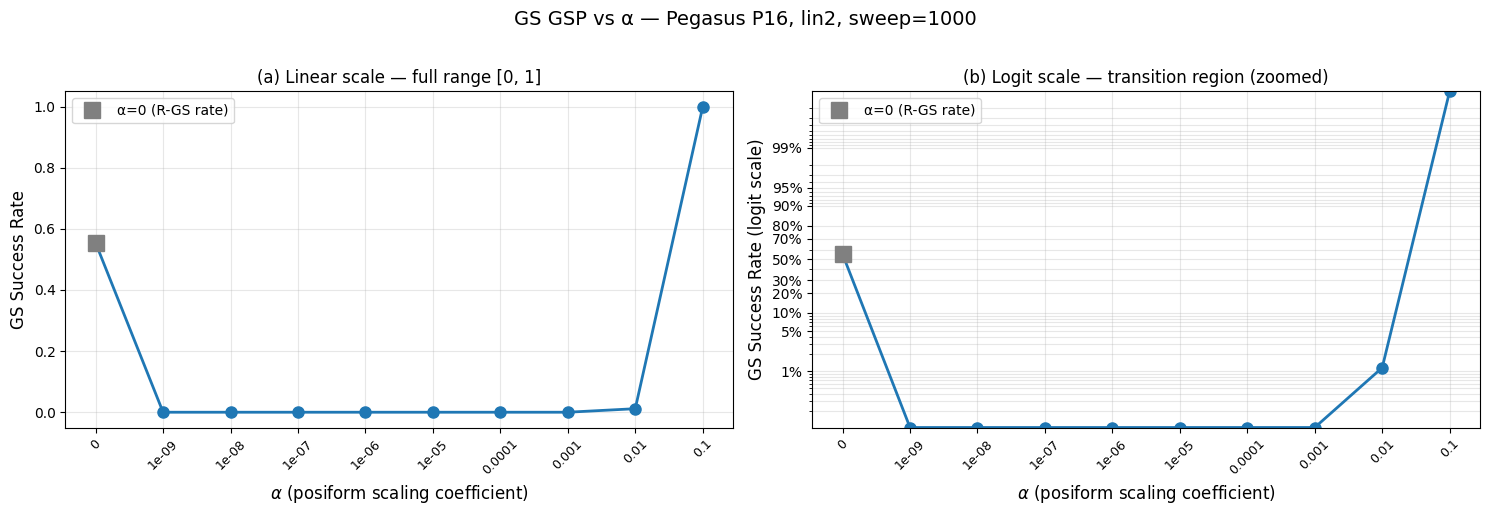


══════════════════════════════════════════════════════════════════════════════════════════════════════════════
  총 200 인스턴스 × 10 α × 100 reads = 200,000 SA 샘플
══════════════════════════════════════════════════════════════════════════════════════════════════════════════
α                          GS 성공률                Bit 성공률             Energy 성공률     Avg HD
──────────────────────────────────────────────────────────────────────────────────────────────────────────────
0           11076/20000 ( 55.4%)      0/20000 (  0.0%)  11076/20000 ( 55.4%)   45862.2
1e-09           0/20000 (  0.0%)      0/20000 (  0.0%)      0/20000 (  0.0%)    6961.3
1e-08           0/20000 (  0.0%)      0/20000 (  0.0%)      0/20000 (  0.0%)    6943.4
1e-07           0/20000 (  0.0%)      0/20000 (  0.0%)      0/20000 (  0.0%)    6947.0
1e-06           0/20000 (  0.0%)      0/20000 (  0.0%)      0/20000 (  0.0%)    6947.4
1e-05           0/20000 (  0.0%)      0/20000 (  0.0%)      0/20000 (  0.0%)    6925.6
0.000

In [9]:
# ═══ GSP vs α (sweep=1000 고정) ═══
# [수정 사항]
#   1) [전략 1] α 하한을 float64 안전 구간 (≥ 1e-14)으로 제한
#   2) abs(v) > 1e-15 필터 제거 (0이 아닌 값 모두 유지)
#   3) time/numpy 명시 import, NUM_WORKERS 음수 가드, 에러 카운트 수정
#   4) [전략 2 제거] P 정규화는 paper와 α 축 비교를 깨고 neal auto-beta를 망가뜨려 제거
#   5) 시각화: linear + logit 2 패널로 전이 영역 가독성 개선
#   6) 청크 병렬 + fork context (OOM/spawn 회피)
#   7) [추가] Energy 성공률 외에 Bit 성공률(target과 정확히 일치) + Avg HD(Hamming distance) 측정
#   8) [통합 GS metric] gsp_gs:
#        α=0: R-축퇴 GS이므로 partition-wise GS membership 검사 (target과 다른 R-GS도 OK)
#        α>0: target이 unique GS이므로 sample == target_str (= gsp_bit)
#      → 부동소수점 우회. paper main metric으로 사용 권장.
import matplotlib.pyplot as plt
import json
import os
import time
import numpy as np
from datetime import datetime
from concurrent.futures import ProcessPoolExecutor, as_completed
import gc
gc.collect()
# ─── 하이퍼파라미터 ───
TOPO = 'pegasus'            # 'pegasus', 'zephyr', 'chimera'
TOPO_SIZE = 16              # pegasus=16, zephyr=4, chimera=16
COEFF = 'lin2'             # 'lin2', 'lin20'
NUM_INSTANCES = 200         # 200 or 500 or 1000

# [전략 1] 안전 α 범위: ε_mach(≈2.22e-16) 기준 10~100× 여유
# α_raw 단위 (3월 실험과 동일 축, paper convention)
alphas_gsp = [0, 1e-9, 1e-8, 1e-7, 1e-6,
              1e-5, 1e-4, 1e-3, 1e-2, 1e-1]
fixed_sweep = 1000
num_reads_gsp = 100
# [OOM 방지] 워커 수 제한 (16GB RAM 기준 3 워커 안정)
NUM_WORKERS = max(1, min(os.cpu_count() - 2, 3))
CHUNK_SIZE = 30

# ─── 인스턴스 로드 ───
inst_list, inst_meta = load_instances(NUM_INSTANCES, topo=TOPO, topo_size=TOPO_SIZE, coeff=COEFF)
topo_label = f"{inst_meta['topology'].capitalize()} {inst_meta['topology'][0].upper()}{inst_meta['topo_size']}"

# 인스턴스에 all_block_gs, partitions 키 있는지 확인 (없으면 셀 8 재실행 필요)
if 'all_block_gs' not in inst_list[0] or 'partitions' not in inst_list[0]:
    raise RuntimeError(
        "인스턴스에 'all_block_gs' 또는 'partitions' 키가 없음. "
        "셀 8을 재실행해서 인스턴스를 다시 생성하세요 (gsp_gs metric에 필요).")

# ─── 결과 디렉토리 ───
base_results_dir = os.path.join(_resolve_base_dir(), 'results')
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
run_dir_gsp = os.path.join(base_results_dir,
    f'gsp_vs_alpha_{inst_meta["topology"]}{inst_meta["topo_size"]}_{inst_meta["coeff"]}_inst{NUM_INSTANCES}_{timestamp}')
os.makedirs(run_dir_gsp, exist_ok=True)

print(f"═══ GSP vs α (sweep={fixed_sweep}) ═══")
print(f"  topology: {topo_label}, coeff: {inst_meta['coeff']}")
print(f"  alphas (raw): {alphas_gsp}")
print(f"  instances: {NUM_INSTANCES}, reads: {num_reads_gsp}, workers: {NUM_WORKERS}")
print(f"  결과 디렉토리: {run_dir_gsp}")

# ─── SA worker ───
# [측정] Energy / Bit / GS (통합) / Avg HD 모두 측정.
#   - Energy: abs(energy - target_energy) < 1e-10  (부동소수점 영향 받음)
#   - Bit:    found_str == target_str             (target exact match만)
#   - GS:     α=0 → _is_R_gs / α>0 → bit match    (paper main metric)
#   - HD:     평균 Hamming distance from target
def sa_worker_gsp(args):
    try:
        import neal
        (Q_dict, num_reads, num_sweeps, alpha, target_energy,
         target_str, sorted_nodes, all_block_gs, partitions) = args
        sampler = neal.SimulatedAnnealingSampler()
        resp = sampler.sample_qubo(Q_dict, num_reads=num_reads, num_sweeps=num_sweeps)
        best_energy = float('inf')
        eng_found = 0
        bit_found = 0
        gs_found = 0
        hd_sum = 0
        for sample, energy, _ in resp.data(['sample', 'energy', 'num_occurrences']):
            best_energy = min(best_energy, energy)
            if abs(energy - target_energy) < 1e-10:
                eng_found += 1
            found_str = ''.join(str(sample[nd]) for nd in sorted_nodes)
            hd = sum(1 for a, b in zip(target_str, found_str) if a != b)
            hd_sum += hd
            is_target = (found_str == target_str)
            if is_target:
                bit_found += 1
            # 통합 GS metric: α=0이면 R-GS membership / α>0이면 target exact
            if alpha == 0:
                if _is_R_gs(sample, all_block_gs, partitions):
                    gs_found += 1
            else:
                if is_target:
                    gs_found += 1
        del Q_dict, resp, sampler
        return ('OK', eng_found, bit_found, gs_found, hd_sum,
                best_energy - target_energy, num_reads)
    except Exception as e:
        try:
            return ('ERR', str(e), 0, 0, 0, 0, 0.0, args[1])
        except Exception:
            return ('ERR', str(e), 0, 0, 0, 0, 0.0, 0)

# ─── SA 실험 (청크 병렬 + executor 재사용) ───
print(f"\nSA 실험 중... (workers={NUM_WORKERS}, chunk={CHUNK_SIZE})")
gsp_results = {}
errors = []

# [OOM 방지] 시작 전 가비지 컬렉션 → fork 시 부모 메모리 최소화
import gc
gc.collect()

t0 = time.perf_counter()

# fork context 강제 (spawn에서 notebook 함수 못 찾는 문제 회피)
import multiprocessing as _mp
try:
    _fork_ctx = _mp.get_context('fork')
except ValueError:
    _fork_ctx = None

if _fork_ctx is not None:
    executor = ProcessPoolExecutor(max_workers=NUM_WORKERS, mp_context=_fork_ctx)
else:
    executor = ProcessPoolExecutor(max_workers=NUM_WORKERS)

with executor:
    for ai, alpha in enumerate(alphas_gsp):
        eng_total = 0
        bit_total = 0
        gs_total = 0
        hd_total = 0
        reads_total = 0

        for chunk_start in range(0, len(inst_list), CHUNK_SIZE):
            chunk = inst_list[chunk_start:chunk_start + CHUNK_SIZE]

            tasks = []
            for inst in chunk:
                Q_dict = dict(inst['R_sum'])
                for k, v in inst['P'].items():
                    Q_dict[k] = Q_dict.get(k, 0) + alpha * v
                Q_dict = {k: v for k, v in Q_dict.items() if v != 0.0}
                t_energy = inst['t_energy_r'] + alpha * inst['t_energy_p']
                tasks.append((Q_dict, num_reads_gsp, fixed_sweep, alpha, t_energy,
                              inst['target_str'], inst['sorted_nodes'],
                              inst['all_block_gs'], inst['partitions']))

            futures = [executor.submit(sa_worker_gsp, task) for task in tasks]
            for future in as_completed(futures):
                result = future.result()
                if result[0] == 'OK':
                    _, eng_found, bit_found, gs_found, hd_sum, de_best, n_reads = result
                    eng_total += eng_found
                    bit_total += bit_found
                    gs_total += gs_found
                    hd_total += hd_sum
                    reads_total += n_reads
                else:
                    _, err_msg, _, _, _, _, _, n_reads = result
                    reads_total += n_reads
                    errors.append((alpha, err_msg))
                    if len(errors) <= 3:
                        print(f"  [worker error] α={alpha}: {err_msg}")

            del tasks, futures

        gsp_eng = eng_total / reads_total if reads_total > 0 else 0
        gsp_bit = bit_total / reads_total if reads_total > 0 else 0
        gsp_gs = gs_total / reads_total if reads_total > 0 else 0
        avg_hd = hd_total / NUM_INSTANCES if NUM_INSTANCES > 0 else 0
        gsp_results[alpha] = {
            'gsp_eng': gsp_eng, 'gsp_bit': gsp_bit, 'gsp_gs': gsp_gs,
            'eng_ok': eng_total, 'bit_ok': bit_total, 'gs_ok': gs_total,
            'hd_sum': hd_total, 'avg_hd': avg_hd,
            'total': reads_total,
            'eng_found': eng_total,  # backward compat
        }

        elapsed = time.perf_counter() - t0
        eta = elapsed / (ai + 1) * (len(alphas_gsp) - ai - 1)
        print(f"  α={alpha:<10}: GS={gsp_gs:.3f} Bit={gsp_bit:.3f} Eng={gsp_eng:.3f} HD={avg_hd:.1f} "
              f"[{ai+1}/{len(alphas_gsp)}, {elapsed:.0f}s, ETA {eta:.0f}s]")

elapsed = time.perf_counter() - t0
print(f"\n  완료: {elapsed:.1f}s")
if errors:
    print(f"  [경고] 워커 에러 {len(errors)}건 발생")

# ─── 시각화 (2 패널: linear + logit) — main metric: gsp_gs ───
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
alpha_vals = list(alphas_gsp)
gsp_vals = [gsp_results[a]['gsp_gs'] for a in alphas_gsp]  # 통합 GS metric

# ── (a) 선형 y축 [0, 1] — 전체 개요 ──
ax = axes[0]
ax.plot(range(len(alpha_vals)), gsp_vals, 'o-', color='tab:blue',
        markersize=8, linewidth=2)
ax.plot(0, gsp_vals[0], 's', color='gray', markersize=12, zorder=5,
        label='α=0 (R-GS rate)')
ax.set_xticks(range(len(alpha_vals)))
ax.set_xticklabels([str(a) for a in alpha_vals], fontsize=9, rotation=45)
ax.set_xlabel(r'$\alpha$ (posiform scaling coefficient)', fontsize=12)
ax.set_ylabel('GS Success Rate', fontsize=12)
ax.set_title(f'(a) Linear scale — full range [0, 1]', fontsize=12)
ax.set_ylim(-0.05, 1.05)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# ── (b) logit 스케일 — 전이 영역 확대 ──
ax = axes[1]
eps = 1e-3
gsp_clipped = np.clip(gsp_vals, eps, 1 - eps)
ax.plot(range(len(alpha_vals)), gsp_clipped, 'o-', color='tab:blue',
        markersize=8, linewidth=2)
ax.plot(0, gsp_clipped[0], 's', color='gray', markersize=12, zorder=5,
        label='α=0 (R-GS rate)')
ax.set_xticks(range(len(alpha_vals)))
ax.set_xticklabels([str(a) for a in alpha_vals], fontsize=9, rotation=45)
ax.set_xlabel(r'$\alpha$ (posiform scaling coefficient)', fontsize=12)
ax.set_ylabel('GS Success Rate (logit scale)', fontsize=12)
ax.set_title(f'(b) Logit scale — transition region (zoomed)', fontsize=12)
try:
    ax.set_yscale('logit')
    yticks = [0.01, 0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 0.8, 0.9, 0.95, 0.99]
    ax.set_yticks(yticks)
    ax.set_yticklabels([f'{y:.0%}' for y in yticks])
except Exception:
    ax.set_yscale('function', functions=(lambda p: np.log(p/(1-p+1e-12)+1e-12),
                                          lambda q: 1/(1+np.exp(-q))))
ax.set_ylim(eps, 1 - eps)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, which='both')

fig.suptitle(f'GS GSP vs α — {topo_label}, {inst_meta["coeff"]}, sweep={fixed_sweep}',
             fontsize=14, y=1.02)
plt.tight_layout()
fig.savefig(os.path.join(run_dir_gsp, 'gsp_vs_alpha.png'), dpi=200, bbox_inches='tight')
fig.savefig(os.path.join(run_dir_gsp, 'gsp_vs_alpha.pdf'), bbox_inches='tight')
plt.show()

# ── (c) 선형 y축 단독 (기존 1-패널 호환용) ──
fig2, ax2 = plt.subplots(figsize=(9, 5))
ax2.plot(range(len(alpha_vals)), gsp_vals, 'o-', color='tab:blue',
         markersize=8, linewidth=2)
ax2.plot(0, gsp_vals[0], 's', color='gray', markersize=12, zorder=5,
         label='α=0 (R-GS rate)')
ax2.set_xticks(range(len(alpha_vals)))
ax2.set_xticklabels([str(a) for a in alpha_vals], fontsize=10, rotation=45)
ax2.set_xlabel(r'$\alpha$ (posiform scaling coefficient)', fontsize=13)
ax2.set_ylabel('GS Success Rate', fontsize=13)
ax2.set_title(f'GS GSP vs α — {topo_label}, {inst_meta["coeff"]}, sweep={fixed_sweep}', fontsize=14)
ax2.set_ylim(-0.05, 1.05)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)
plt.tight_layout()
fig2.savefig(os.path.join(run_dir_gsp, 'gsp_vs_alpha_linear.png'), dpi=200)
fig2.savefig(os.path.join(run_dir_gsp, 'gsp_vs_alpha_linear.pdf'))
plt.close(fig2)

# ─── 결과 테이블 (posiform.ipynb 스타일) ───
print(f"\n{'═' * 110}")
print(f"  총 {NUM_INSTANCES} 인스턴스 × {len(alphas_gsp)} α × {num_reads_gsp} reads = "
      f"{NUM_INSTANCES * len(alphas_gsp) * num_reads_gsp:,} SA 샘플")
print(f"{'═' * 110}")
print(f"{'α':<10} {'GS 성공률':>22} {'Bit 성공률':>22} {'Energy 성공률':>22} {'Avg HD':>10}")
print(f"{'─' * 110}")
for alpha in alphas_gsp:
    r = gsp_results[alpha]
    eng_rate = 100 * r['eng_ok'] / r['total'] if r['total'] else 0
    bit_rate = 100 * r['bit_ok'] / r['total'] if r['total'] else 0
    gs_rate = 100 * r['gs_ok'] / r['total'] if r['total'] else 0
    print(f"{alpha:<10} {r['gs_ok']:>6}/{r['total']} ({gs_rate:>5.1f}%) "
          f"{r['bit_ok']:>6}/{r['total']} ({bit_rate:>5.1f}%) "
          f"{r['eng_ok']:>6}/{r['total']} ({eng_rate:>5.1f}%) {r['avg_hd']:>9.1f}")
print(f"{'─' * 110}")

# ─── README + JSON ───
md_path = os.path.join(run_dir_gsp, 'README.md')
with open(md_path, 'w') as f:
    f.write(f"# GSP vs α 실험 결과\n\n")
    f.write(f"**날짜**: {datetime.now().strftime('%Y-%m-%d %H:%M')}\n\n")
    f.write(f"## 실험 설정\n\n")
    f.write(f"| 항목 | 값 |\n|---|---|\n")
    f.write(f"| Topology | {topo_label} (n={inst_meta['n']}) |\n")
    f.write(f"| coeff_type | {inst_meta['coeff']} |\n")
    f.write(f"| α | {alphas_gsp} |\n")
    f.write(f"| sweep | {fixed_sweep} |\n")
    f.write(f"| num_reads | {num_reads_gsp} |\n")
    f.write(f"| num_instances | {NUM_INSTANCES} |\n")
    f.write(f"| 총 소요 시간 | {elapsed:.1f}s |\n\n")
    f.write(f"**Main metric**: `gsp_gs` — α=0이면 R-축퇴 GS partition-wise 검사, α>0이면 target exact match. 부동소수점 우회.\n\n")
    f.write(f"## 결과 요약 (GS / Bit / Energy / HD)\n\n")
    f.write(f"| α | GS 성공률 | Bit 성공률 | Energy 성공률 | Avg HD |\n")
    f.write(f"|---|---|---|---|---|\n")
    for alpha in alphas_gsp:
        r = gsp_results[alpha]
        eng_rate = 100 * r['eng_ok'] / r['total'] if r['total'] else 0
        bit_rate = 100 * r['bit_ok'] / r['total'] if r['total'] else 0
        gs_rate = 100 * r['gs_ok'] / r['total'] if r['total'] else 0
        f.write(f"| {alpha} | {r['gs_ok']}/{r['total']} ({gs_rate:.1f}%) "
                f"| {r['bit_ok']}/{r['total']} ({bit_rate:.1f}%) "
                f"| {r['eng_ok']}/{r['total']} ({eng_rate:.1f}%) | {r['avg_hd']:.1f} |\n")
    f.write(f"\n## 파일 목록\n\n")
    f.write(f"- `gsp_vs_alpha.png/pdf` — Fig (linear + logit 2-panel, gsp_gs main metric)\n")
    f.write(f"- `gsp_vs_alpha_linear.png/pdf` — Fig (linear 단독)\n")
    f.write(f"- `data.json` — 전체 데이터\n")

json_path = os.path.join(run_dir_gsp, 'data.json')
with open(json_path, 'w') as f:
    json.dump({
        'params': {
            'topology': inst_meta['topology'], 'topo_size': inst_meta['topo_size'],
            'coeff': inst_meta['coeff'], 'num_instances': NUM_INSTANCES,
            'num_reads': num_reads_gsp, 'fixed_sweep': fixed_sweep,
            'alphas': alphas_gsp, 'elapsed_s': round(elapsed, 1),
        },
        'results': {str(a): gsp_results[a] for a in alphas_gsp},
    }, f, indent=2)

print(f"  ═══ 결과: {run_dir_gsp} ═══")

## 10. QPU: GSP vs α (D-Wave Advantage)

점검 셀(## 7)의 토큰·active set을 활용. 실험 셀의 `alphas_qpu`를 Session 1/2 set으로 변경 후 실행.

  로드: instances_pegasus16_lin2_100.pkl (100개, n=5612, Δ_P=1.7700, Δ_R=1.00)
QPU: Advantage_system6.4 (인스턴스 메타: Advantage_system6.4)
Qubits: 5760
Topology: pegasus
annealing_time_range: [0.5, 2000.0] μs
Active qubits: 5612, Active couplers: 40088

  인스턴스 호환성: 100/100 valid

═══ QPU GSP vs α × anneal time (full data) ═══
  topology: Pegasus P16, coeff: lin2
  alphas: [0, 0.001, 0.01, 0.05, 0.1]
  anneal_times: [0.5, 2000.0] μs
  num_reads: 100, instances: 100
  결과 디렉토리: /home/yideun/qubo_dataset/hardened_posiform/results/qpu_gsp_vs_alpha_anneal_pegasus16_lin2_inst100_20260430_211426
  raw 디렉토리: /home/yideun/qubo_dataset/hardened_posiform/results/qpu_gsp_vs_alpha_anneal_pegasus16_lin2_inst100_20260430_211426/raw (combo별 pickle)

QPU 실험 중...
  α=0      T=0.5    μs: GS=0.000 Bit=0.000 Eng=0.000 HD=62069.5 raw=55.2MB [1/10, 124s, ETA 1116s]
  α=0      T=2000.0 μs: GS=0.249 Bit=0.000 Eng=0.249 HD=44070.2 raw=55.2MB [2/10, 262s, ETA 1050s]
  α=0.001  T=0.5    μs: GS=0.000 Bit=0.000 Eng=0.000 H

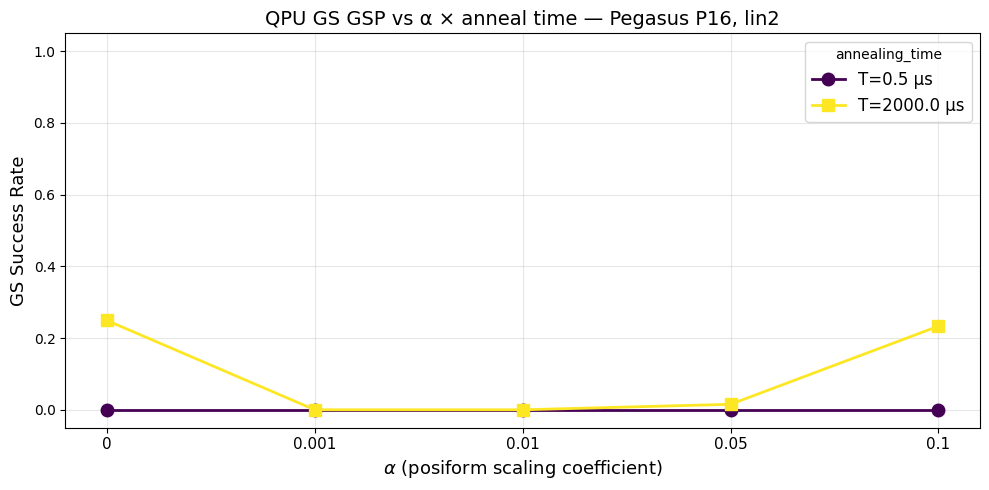


══════════════════════════════════════════════════════════════════════════════════════════════════════════════
  총 100 인스턴스 × 5 α × 2 T × 100 reads
══════════════════════════════════════════════════════════════════════════════════════════════════════════════
α        T(μs)              GS        Bit        Eng     Avg HD
──────────────────────────────────────────────────────────────────────────────────────────────────────────────
0        0.5             0.000      0.000      0.000    62069.5
0        2000.0          0.249      0.000      0.249    44070.2
0.001    0.5             0.000      0.000      0.000    59659.8
0.001    2000.0          0.000      0.000      0.000    39788.9
0.01     0.5             0.000      0.000      0.000    41281.9
0.01     2000.0          0.000      0.000      0.000    13587.4
0.05     0.5             0.000      0.000      0.000     8979.9
0.05     2000.0          0.015      0.015      0.012      790.2
0.1      0.5             0.000      0.000      0.000 

In [29]:
# ═══ QPU: GSP vs α × anneal time (full data 저장) ═══
# [측정] Energy / Bit / GS (통합 main metric) / Avg HD
# [Sweep] alphas_qpu × anneal_times 2D
# [데이터 저장]
#   - data.json: 집계 + per-instance metrics + timing summary
#   - raw_samples.pkl: per (α, T, inst) raw bits/energies/occurrences/timing
#     → paper post-hoc 분석용 (어느 R-GS 찾았는지 등)
from dwave.system import DWaveSampler, FixedEmbeddingComposite
import matplotlib.pyplot as plt
import json
import os
import pickle
import numpy as np
from datetime import datetime

# ═══ API 토큰 ═══
MY_TOKEN = "yXwP-644aea66ae6f2920550b5c28a53d47e018fdf32e" # ← "DEV-xxxxx" 형태로 변경

# ─── 하이퍼파라미터 ───
TOPO = 'pegasus'
TOPO_SIZE = 16
COEFF = 'lin2'
NUM_INSTANCES = 100

alphas_qpu = [0, 0.001, 0.01, 0.05, 0.1]
anneal_times = [0.5, 2000.0]   # μs
qpu_num_reads = 100

# ─── 인스턴스 로드 (먼저: 메타에서 만들 때 쓴 solver 이름을 가져와야 함) ───
inst_list_qpu, inst_meta_qpu = load_instances(NUM_INSTANCES, topo=TOPO, topo_size=TOPO_SIZE, coeff=COEFF)
topo_label = f"{inst_meta_qpu['topology'].capitalize()} {inst_meta_qpu['topology'][0].upper()}{inst_meta_qpu['topo_size']}"

if 'all_block_gs' not in inst_list_qpu[0] or 'partitions' not in inst_list_qpu[0]:
    raise RuntimeError("인스턴스에 'all_block_gs' 또는 'partitions' 키 없음 — 셀 8 재실행 필요.")

# ─── QPU 연결 (인스턴스 만든 솔버와 동일한 칩으로 고정) ───
# topology 자동 선택('topology__type')은 계정에 같은 토폴로지의 다른 칩이 있으면
# 셀마다 다른 칩을 잡을 수 있음 (예: pegasus → Advantage_system4.1 vs 6.4).
# 인스턴스는 특정 칩의 active set 위에 박혀있으니 같은 칩을 명시 고정.
inst_solver = inst_meta_qpu.get('qpu_solver')
if not inst_solver:
    print(f"  [⚠] 인스턴스 메타에 'qpu_solver' 없음 — 자동 선택으로 fallback")
    solver_filter = {'topology__type': TOPO}
else:
    solver_filter = {'name': inst_solver}

if MY_TOKEN:
    qpu = DWaveSampler(token=MY_TOKEN, solver=solver_filter)
else:
    qpu = DWaveSampler(solver=solver_filter)

print(f"QPU: {qpu.solver.name} (인스턴스 메타: {inst_solver or 'N/A'})")
print(f"Qubits: {qpu.solver.num_qubits}")
topo_type = qpu.properties.get('topology', {}).get('type', 'unknown')
print(f"Topology: {topo_type}")

trange = qpu.properties.get('annealing_time_range', [0.5, 2000.0])
print(f"annealing_time_range: {trange} μs")
for T in anneal_times:
    if T < trange[0] or T > trange[1]:
        raise ValueError(f"annealing_time={T} μs out of QPU range {trange}")

qpu_nodes = set(qpu.nodelist)
qpu_edges = set(map(lambda e: (min(e), max(e)), qpu.edgelist))
print(f"Active qubits: {len(qpu_nodes)}, Active couplers: {len(qpu_edges)}")

valid_instances = []
for inst in inst_list_qpu:
    qubo_nodes, qubo_edges = _extract_inst_topo(inst)
    if qubo_nodes.issubset(qpu_nodes) and qubo_edges.issubset(qpu_edges):
        valid_instances.append(inst)

print(f"\n  인스턴스 호환성: {len(valid_instances)}/{len(inst_list_qpu)} valid")
inst_cache_qpu = valid_instances

# ─── 가드: valid_instances == 0이면 즉시 에러 (silent 0 결과 방지) ───
if len(inst_cache_qpu) == 0:
    n0, e0 = _extract_inst_topo(inst_list_qpu[0])
    miss_n = n0 - qpu_nodes
    miss_e = e0 - qpu_edges
    raise RuntimeError(
        f"valid_instances == 0. 인스턴스가 현재 QPU active set에 맞지 않음.\n"
        f"  인스턴스 만든 솔버: {inst_solver}, 현재 솔버: {qpu.solver.name}\n"
        f"  inst0 missing nodes: {len(miss_n)}, edges: {len(miss_e)}\n"
        f"  → 솔버가 다르거나 calibration drift. 셀 15(인스턴스 생성)를 다시 실행하세요.")

# ─── 결과 디렉토리 ───
base_results_dir = os.path.join(_resolve_base_dir(), 'results')
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
run_dir_qpu = os.path.join(base_results_dir,
    f'qpu_gsp_vs_alpha_anneal_{inst_meta_qpu["topology"]}{inst_meta_qpu["topo_size"]}_{inst_meta_qpu["coeff"]}_inst{len(inst_cache_qpu)}_{timestamp}')
os.makedirs(run_dir_qpu, exist_ok=True)
raw_dir = os.path.join(run_dir_qpu, 'raw')
os.makedirs(raw_dir, exist_ok=True)

print(f"\n═══ QPU GSP vs α × anneal time (full data) ═══")
print(f"  topology: {topo_label}, coeff: {inst_meta_qpu['coeff']}")
print(f"  alphas: {alphas_qpu}")
print(f"  anneal_times: {anneal_times} μs")
print(f"  num_reads: {qpu_num_reads}, instances: {len(inst_cache_qpu)}")
print(f"  결과 디렉토리: {run_dir_qpu}")
print(f"  raw 디렉토리: {raw_dir} (combo별 pickle)")

# ─── QPU 실험 ───
print(f"\nQPU 실험 중...")
qpu_results = {}        # 집계 (key: (alpha, T))
per_instance_data = {}  # per-instance metrics (key: (alpha, T))

t0 = time.perf_counter()
total_combos = len(alphas_qpu) * len(anneal_times)
combo_idx = 0

for ai, alpha in enumerate(alphas_qpu):
    for ti, T in enumerate(anneal_times):
        combo_idx += 1
        eng_total = 0
        bit_total = 0
        gs_total = 0
        hd_total = 0
        reads_total = 0

        # per-instance raw 저장 컨테이너
        combo_raw = {
            'alpha': alpha,
            'T': T,
            'coeff': COEFF,
            'qpu_solver': qpu.solver.name,
            'inst_indices': [],
            'sorted_nodes_per_inst': [],   # 각 inst의 sorted_nodes (인덱싱용)
            'bits': [],                    # numpy uint8 array per inst, shape (num_reads, n_inst_nodes)
            'energies': [],                # numpy float64 array per inst
            'num_occurrences': [],         # numpy int array per inst
            'timings': [],                 # dict per inst (qpu access timing)
            'per_instance_metrics': [],    # dict per inst (eng_ok, bit_ok, gs_ok, hd_sum)
            'errors': [],                  # any per-inst errors
        }

        for inst_idx, cache in enumerate(inst_cache_qpu):
            Q_dict = dict(cache['R_sum'])
            for k, v in cache['P'].items():
                Q_dict[k] = Q_dict.get(k, 0) + alpha * v
            Q_dict = {k: v for k, v in Q_dict.items() if abs(v) > 1e-15}

            t_energy = cache['t_energy_r'] + alpha * cache['t_energy_p']
            target_str = cache['target_str']
            sorted_nodes = cache['sorted_nodes']
            all_block_gs = cache['all_block_gs']
            partitions = cache['partitions']

            qubo_nodes_inst = set()
            for (i, j) in Q_dict:
                qubo_nodes_inst.add(i)
                if i != j:
                    qubo_nodes_inst.add(j)
            identity_emb = {v: [v] for v in qubo_nodes_inst}

            inst_eng = inst_bit = inst_gs = 0
            inst_hd = 0
            inst_reads = 0

            try:
                qpu_sampler = FixedEmbeddingComposite(qpu, embedding=identity_emb)
                resp = qpu_sampler.sample_qubo(Q_dict, num_reads=qpu_num_reads,
                                                annealing_time=T)

                # raw 저장: bits/energies/occurrences를 numpy로
                samples_data = list(resp.data(['sample', 'energy', 'num_occurrences']))
                n_samples = len(samples_data)
                n_nodes = len(sorted_nodes)
                bits_arr = np.zeros((n_samples, n_nodes), dtype=np.uint8)
                energies_arr = np.zeros(n_samples, dtype=np.float64)
                occ_arr = np.zeros(n_samples, dtype=np.int32)

                for r, (sample, energy, num) in enumerate(samples_data):
                    energies_arr[r] = energy
                    occ_arr[r] = num
                    for c, v in enumerate(sorted_nodes):
                        bits_arr[r, c] = sample[v]

                    # 동시 metric 측정 — num_occurrences로 가중치 부여
                    # (D-Wave 기본 answer_mode='histogram'이라 동일 샘플이 합쳐져서 옴)
                    inst_reads += int(num)
                    # tolerance 1e-9: D-Wave가 반환하는 energy는 host-side Q dict로
                    # 재계산한 값(float64)이라 round-off만 발생. SA 셀(1e-10)과 통일.
                    # 1e-9는 α×P 곱셈 누적 오차에 대한 약간의 여유.
                    if abs(energy - t_energy) < 1e-9:
                        inst_eng += int(num)
                    found_str = ''.join(str(sample[v]) for v in sorted_nodes)
                    hd = sum(1 for a, b in zip(target_str, found_str) if a != b)
                    inst_hd += hd * int(num)
                    is_target = (found_str == target_str)
                    if is_target:
                        inst_bit += int(num)
                    if alpha == 0:
                        if _is_R_gs(sample, all_block_gs, partitions):
                            inst_gs += int(num)
                    else:
                        if is_target:
                            inst_gs += int(num)

                # raw append
                combo_raw['inst_indices'].append(inst_idx)
                combo_raw['sorted_nodes_per_inst'].append(sorted_nodes)
                combo_raw['bits'].append(bits_arr)
                combo_raw['energies'].append(energies_arr)
                combo_raw['num_occurrences'].append(occ_arr)
                combo_raw['timings'].append(dict(resp.info.get('timing', {})))

            except Exception as e:
                combo_raw['errors'].append({'inst_idx': inst_idx, 'error': str(e)})
                if inst_idx == 0:
                    print(f"  [Warning] α={alpha}, T={T}μs, inst 0: {e}")
                # 에러 인스턴스는 통계에서 제외 (분모 부풀림 방지)
                # → inst_reads/inst_eng/inst_bit/inst_gs/inst_hd 모두 0 유지
                # bits/energies/occurrences는 raw에 누락, errors에만 기록

            # 누적
            eng_total += inst_eng
            bit_total += inst_bit
            gs_total += inst_gs
            hd_total += inst_hd
            reads_total += inst_reads

            # per-instance metrics
            combo_raw['per_instance_metrics'].append({
                'inst_idx': inst_idx,
                'eng_ok': inst_eng,
                'bit_ok': inst_bit,
                'gs_ok': inst_gs,
                'hd_sum': inst_hd,
                'reads': inst_reads,
            })

        # 집계
        gsp_eng = eng_total / reads_total if reads_total > 0 else 0
        gsp_bit = bit_total / reads_total if reads_total > 0 else 0
        gsp_gs = gs_total / reads_total if reads_total > 0 else 0
        n_inst = len(inst_cache_qpu)
        avg_hd = hd_total / n_inst if n_inst > 0 else 0
        qpu_results[(alpha, T)] = {
            'gsp_eng': gsp_eng, 'gsp_bit': gsp_bit, 'gsp_gs': gsp_gs,
            'eng_ok': eng_total, 'bit_ok': bit_total, 'gs_ok': gs_total,
            'hd_sum': hd_total, 'avg_hd': avg_hd,
            'total': reads_total,
            'num_errors': len(combo_raw['errors']),
        }
        per_instance_data[(alpha, T)] = combo_raw['per_instance_metrics']

        # raw 저장 (combo별 pickle, 메모리 즉시 해제)
        raw_path = os.path.join(raw_dir, f'raw_alpha{alpha}_T{T}.pkl')
        with open(raw_path, 'wb') as f:
            pickle.dump(combo_raw, f, protocol=pickle.HIGHEST_PROTOCOL)
        raw_size_mb = os.path.getsize(raw_path) / 1024 / 1024
        del combo_raw  # 메모리 해제

        elapsed = time.perf_counter() - t0
        eta = elapsed / combo_idx * (total_combos - combo_idx)
        print(f"  α={alpha:<6} T={T:<7}μs: GS={gsp_gs:.3f} Bit={gsp_bit:.3f} Eng={gsp_eng:.3f} HD={avg_hd:.1f} "
              f"raw={raw_size_mb:.1f}MB [{combo_idx}/{total_combos}, {elapsed:.0f}s, ETA {eta:.0f}s]")

elapsed = time.perf_counter() - t0
print(f"\n  완료: {elapsed:.1f}s")

# ─── 시각화 ───
fig, ax = plt.subplots(figsize=(10, 5))
colors = plt.cm.viridis([i / max(len(anneal_times) - 1, 1) for i in range(len(anneal_times))])
markers = ['o', 's', '^', 'D', 'v']
alpha_vals = list(alphas_qpu)

for ti, T in enumerate(anneal_times):
    vals = [qpu_results[(a, T)]['gsp_gs'] for a in alphas_qpu]
    ax.plot(range(len(alpha_vals)), vals, marker=markers[ti % len(markers)],
            color=colors[ti], linestyle='-', linewidth=2, markersize=9,
            label=f'T={T} μs')

ax.set_xticks(range(len(alpha_vals)))
ax.set_xticklabels([str(a) for a in alpha_vals], fontsize=11)
ax.set_xlabel(r'$\alpha$ (posiform scaling coefficient)', fontsize=13)
ax.set_ylabel('GS Success Rate', fontsize=13)
ax.set_title(f'QPU GS GSP vs α × anneal time — {topo_label}, {inst_meta_qpu["coeff"]}', fontsize=14)
ax.set_ylim(-0.05, 1.05)
ax.legend(fontsize=12, title='annealing_time')
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(os.path.join(run_dir_qpu, 'qpu_gsp_vs_alpha_anneal.png'), dpi=200)
fig.savefig(os.path.join(run_dir_qpu, 'qpu_gsp_vs_alpha_anneal.pdf'))
plt.show()

# ─── 결과 테이블 ───
n_inst = len(inst_cache_qpu)
print(f"\n{'═' * 110}")
print(f"  총 {n_inst} 인스턴스 × {len(alphas_qpu)} α × {len(anneal_times)} T × {qpu_num_reads} reads")
print(f"{'═' * 110}")
print(f"{'α':<8} {'T(μs)':<10} {'GS':>10} {'Bit':>10} {'Eng':>10} {'Avg HD':>10}")
print(f"{'─' * 110}")
for alpha in alphas_qpu:
    for T in anneal_times:
        r = qpu_results[(alpha, T)]
        print(f"{alpha:<8} {T:<10} {r['gsp_gs']:>10.3f} {r['gsp_bit']:>10.3f} "
              f"{r['gsp_eng']:>10.3f} {r['avg_hd']:>10.1f}")
print(f"{'─' * 110}")

# ─── README ───
md_path_qpu = os.path.join(run_dir_qpu, 'README.md')
with open(md_path_qpu, 'w') as f:
    f.write(f"# QPU GSP vs α × anneal time 실험 결과\n\n")
    f.write(f"**날짜**: {datetime.now().strftime('%Y-%m-%d %H:%M')}\n\n")
    f.write(f"## 실험 설정\n\n")
    f.write(f"| 항목 | 값 |\n|---|---|\n")
    f.write(f"| QPU | {qpu.solver.name} |\n")
    f.write(f"| Topology | {topo_label} ({len(qpu_nodes)} active qubits) |\n")
    f.write(f"| coeff_type | {inst_meta_qpu['coeff']} |\n")
    f.write(f"| α | {alphas_qpu} |\n")
    f.write(f"| anneal_times (μs) | {anneal_times} |\n")
    f.write(f"| num_reads | {qpu_num_reads} |\n")
    f.write(f"| num_instances | {len(inst_cache_qpu)} (of {NUM_INSTANCES}) |\n")
    f.write(f"| 총 소요 시간 | {elapsed:.1f}s |\n\n")
    f.write(f"**Main metric**: `gsp_gs` (α=0 R-GS / α>0 target exact)\n\n")
    f.write(f"## 저장된 데이터\n\n")
    f.write(f"- `data.json` — 집계 + per-instance metrics + timing summary\n")
    f.write(f"- `raw/raw_alpha{{α}}_T{{T}}.pkl` — combo별 raw bits/energies/occurrences/timing (post-hoc 분석용)\n")
    f.write(f"- `qpu_gsp_vs_alpha_anneal.png/pdf` — main figure\n\n")
    f.write(f"## 결과 (GS / Bit / Energy / HD)\n\n")
    f.write(f"| α | T(μs) | GS | Bit | Energy | Avg HD |\n")
    f.write(f"|---|---|---|---|---|---|\n")
    for alpha in alphas_qpu:
        for T in anneal_times:
            r = qpu_results[(alpha, T)]
            f.write(f"| {alpha} | {T} | {r['gsp_gs']:.3f} | {r['gsp_bit']:.3f} "
                    f"| {r['gsp_eng']:.3f} | {r['avg_hd']:.1f} |\n")
print(f"  README: {md_path_qpu}")

# ─── JSON (집계 + per-instance metrics) ───
json_qpu = os.path.join(run_dir_qpu, 'data.json')
with open(json_qpu, 'w') as f:
    json.dump({
        'params': {
            'qpu_solver': qpu.solver.name, 'topology': topo_type,
            'topo_size': inst_meta_qpu['topo_size'],
            'coeff': inst_meta_qpu['coeff'],
            'qpu_qubits': len(qpu_nodes),
            'alphas': alphas_qpu, 'anneal_times': anneal_times,
            'num_reads': qpu_num_reads,
            'num_instances': len(inst_cache_qpu),
            'num_instances_requested': NUM_INSTANCES,
            'energy_tol': 0.5, 'elapsed_s': round(elapsed, 1),
            'date': datetime.now().strftime('%Y-%m-%d %H:%M'),
        },
        # nested: results[str(alpha)][str(T)] = aggregate metrics
        'results': {
            str(a): {str(T): qpu_results[(a, T)] for T in anneal_times}
            for a in alphas_qpu
        },
        # per-instance metrics: per_instance[str(alpha)][str(T)] = list of dicts
        'per_instance': {
            str(a): {str(T): per_instance_data[(a, T)] for T in anneal_times}
            for a in alphas_qpu
        },
    }, f, indent=2)
print(f"  JSON: {json_qpu}")

# ─── 디스크 사용량 요약 ───
total_raw_size = sum(os.path.getsize(os.path.join(raw_dir, f))
                     for f in os.listdir(raw_dir)) / 1024 / 1024
print(f"\n  raw/ 디렉토리 총 크기: {total_raw_size:.1f} MB ({len(os.listdir(raw_dir))} files)")
print(f"  ═══ 결과 디렉토리: {run_dir_qpu} ═══")